In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
dataset=pd.read_csv("dataset\dataset.csv")
dataset.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
dataset.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [4]:
dataset.drop("UDI",axis=1,inplace=True)

In [5]:
dataset.drop("Product ID",axis=1,inplace=True)

In [6]:
cols=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF']
for col in cols:
    print(dataset[col].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64
TWF
0    9954
1      46
Name: count, dtype: int64
HDF
0    9885
1     115
Name: count, dtype: int64
PWF
0    9905
1      95
Name: count, dtype: int64
OSF
0    9902
1      98
Name: count, dtype: int64
RNF
0    9981
1      19
Name: count, dtype: int64


In [7]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

dataset["failure_count"] = dataset[failure_cols].sum(axis=1)

print(dataset["failure_count"].value_counts().sort_index())

failure_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64


In [8]:
# Keep only rows with zero or one failure type
dataset_multi = dataset[dataset["failure_count"] <= 1].copy()

# Create failure type
def get_failure_type(row):
    if row["failure_count"] == 0:
        return "No Failure"
    elif row["TWF"] == 1:
        return "TWF"
    elif row["HDF"] == 1:
        return "HDF"
    elif row["PWF"] == 1:
        return "PWF"
    elif row["OSF"] == 1:
        return "OSF"
    elif row["RNF"] == 1:
        return "RNF"

dataset_multi["Failure Type"] = dataset_multi.apply(get_failure_type, axis=1)

print(dataset_multi["Failure Type"].value_counts())

Failure Type
No Failure    9652
HDF            106
PWF             80
OSF             78
TWF             42
RNF             18
Name: count, dtype: int64


In [9]:
X = dataset_multi[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
]

y = dataset_multi["Failure Type"]

In [10]:
dataset["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [11]:
### train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [12]:
### encoding

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X_train['Type']=le.fit_transform(X_train['Type'])
X_test['Type']=le.transform(X_test['Type'])

In [13]:
### model training

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")
rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
## predictions

y_pred=rf.predict(X_test)
y_pred

array(['No Failure', 'No Failure', 'No Failure', ..., 'No Failure',
       'No Failure', 'No Failure'], shape=(1996,), dtype=object)

In [15]:
### model evaluation

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9819639278557114

Classification Report:
              precision    recall  f1-score   support

         HDF       1.00      0.81      0.89        21
  No Failure       0.98      1.00      0.99      1931
         OSF       1.00      0.50      0.67        16
         PWF       0.83      0.31      0.45        16
         RNF       0.00      0.00      0.00         4
         TWF       0.00      0.00      0.00         8

    accuracy                           0.98      1996
   macro avg       0.64      0.44      0.50      1996
weighted avg       0.98      0.98      0.98      1996



c:\Users\Dell\OneDrive\Desktop\code\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\OneDrive\Desktop\code\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\OneDrive\Desktop\code\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

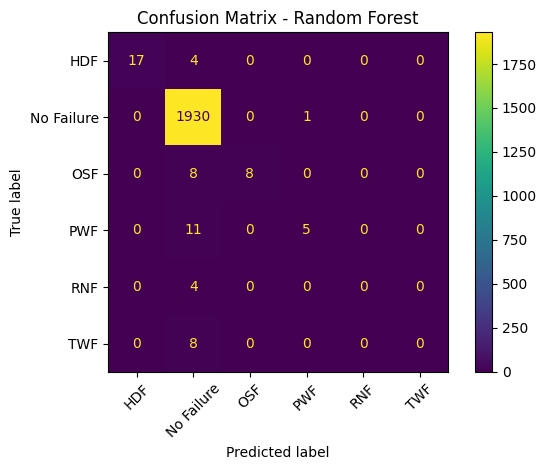

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [17]:
! pip install imblearn

In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Failure Type
No Failure    7721
HDF             85
PWF             64
OSF             62
TWF             34
RNF             14
Name: count, dtype: int64

After SMOTE:
Failure Type
No Failure    7721
OSF           7721
HDF           7721
PWF           7721
TWF           7721
RNF           7721
Name: count, dtype: int64


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred_smote = rf_smote.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_smote = accuracy_score(y_test, y_pred_smote)

print("Accuracy after SMOTE:", accuracy_smote)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_smote,
))

Accuracy after SMOTE: 0.9634268537074149

Classification Report:
              precision    recall  f1-score   support

         HDF       0.75      1.00      0.86        21
  No Failure       0.99      0.97      0.98      1931
         OSF       0.74      0.88      0.80        16
         PWF       0.74      0.88      0.80        16
         RNF       0.00      0.00      0.00         4
         TWF       0.05      0.12      0.07         8

    accuracy                           0.96      1996
   macro avg       0.54      0.64      0.59      1996
weighted avg       0.98      0.96      0.97      1996



In [23]:
rf_params = {
    "n_estimators": [100,150],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [35]:
### hyper paramter tunning

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_smote,
    param_distributions=rf_params,
    n_iter=10,
    cv=4,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train_smote, y_train_smote)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [36]:
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

In [37]:
random_search.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


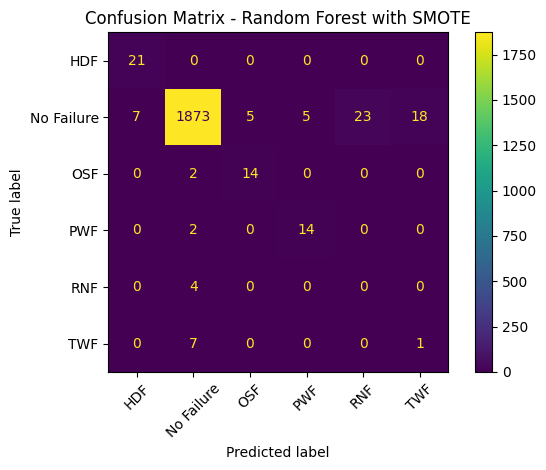

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_smote = confusion_matrix(y_test, y_pred_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=rf_smote.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix - Random Forest with SMOTE")
plt.tight_layout()
plt.show()

In [29]:
## Feature Importance

feature_importance = pd.Series(
    rf_smote.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

Torque [Nm]                0.292576
Tool wear [min]            0.274755
Rotational speed [rpm]     0.206648
Air temperature [K]        0.111311
Process temperature [K]    0.071599
Type                       0.043110
dtype: float64


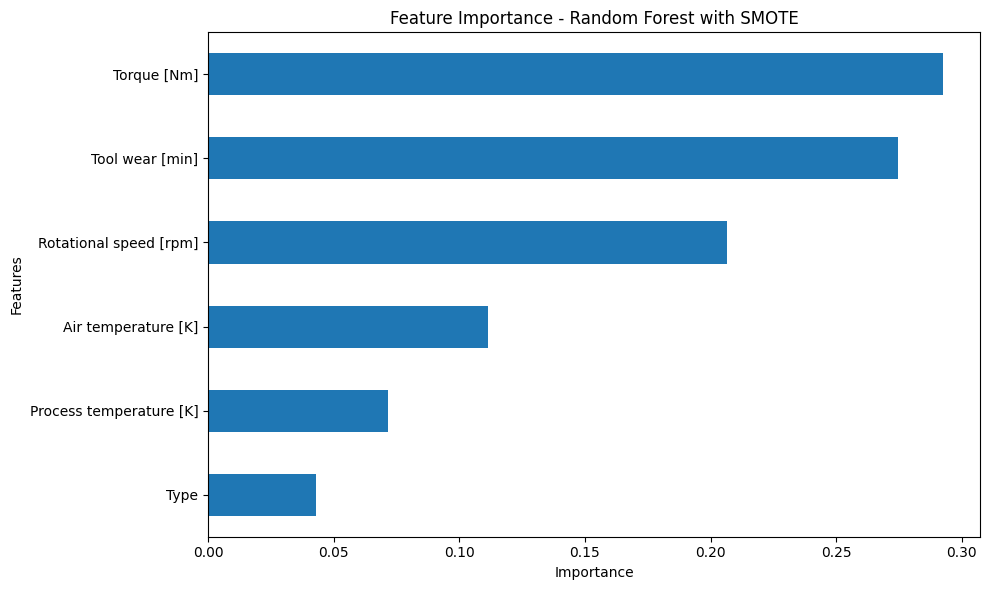

In [30]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Random Forest with SMOTE")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
### model after hyperpara tunning

tunned_model=RandomForestClassifier(n_estimators=100,
 min_samples_split=5,
 min_samples_leaf=1,
 max_features='log2',
 max_depth=None
)

tunned_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred_tunned=tunned_model.predict(X_test)

In [39]:
### model evaluation of tunned model

from sklearn.metrics import accuracy_score, classification_report

print("Tuned Model Accuracy:")
print(accuracy_score(y_test, y_pred_tunned))

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tunned))

Tuned Model Accuracy:
0.9614228456913828

Tuned Model Classification Report:
              precision    recall  f1-score   support

         HDF       0.74      0.95      0.83        21
  No Failure       0.99      0.97      0.98      1931
         OSF       0.74      0.88      0.80        16
         PWF       0.74      0.88      0.80        16
         RNF       0.00      0.00      0.00         4
         TWF       0.05      0.12      0.07         8

    accuracy                           0.96      1996
   macro avg       0.54      0.63      0.58      1996
weighted avg       0.98      0.96      0.97      1996



In [42]:
import pickle

with open("predictive_maintenance_model.pkl", "wb") as file:
    pickle.dump(tunned_model, file)


In [44]:
import pickle

with open("predictive_maintenance_model.pkl", "rb") as file:
    model = pickle.load(file)

prediction = model.predict(new_machine)

In [48]:
### new predictions

new_machine = pd.DataFrame({
    "Type": ["M"],
    "Air temperature [K]": [300.0],
    "Process temperature [K]": [310.0],
    "Rotational speed [rpm]": [1500],
    "Torque [Nm]": [45.0],
    "Tool wear [min]": [100]
})

new_machine["Type"]=le.transform(new_machine["Type"])

In [49]:
model.predict(new_machine)

array(['No Failure'], dtype=object)

In [50]:
### prediction probability

probabilities = model.predict_proba(new_machine)

for class_name, probability in zip(model.classes_, probabilities[0]):
    print(f"{class_name}: {probability:.2%}")

HDF: 0.00%
No Failure: 76.67%
OSF: 0.00%
PWF: 0.00%
RNF: 23.33%
TWF: 0.00%


Model Accuracy Comparison

In [51]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest + SMOTE",
        "Tuned Random Forest + SMOTE"
    ],
    "Accuracy": [
        0.98196,
        0.96343,
        0.96142
    ],
    "Macro F1-Score": [
        0.50,
        0.59,
        0.58
    ]
})

model_comparison

,Model,Accuracy,Macro F1-Score
0,Random Forest,0.98196,0.50
1,Random Forest + SMOTE,0.96343,0.59
2,Tuned Random Forest + SMOTE,0.96142,0.58


Confusion Matrix

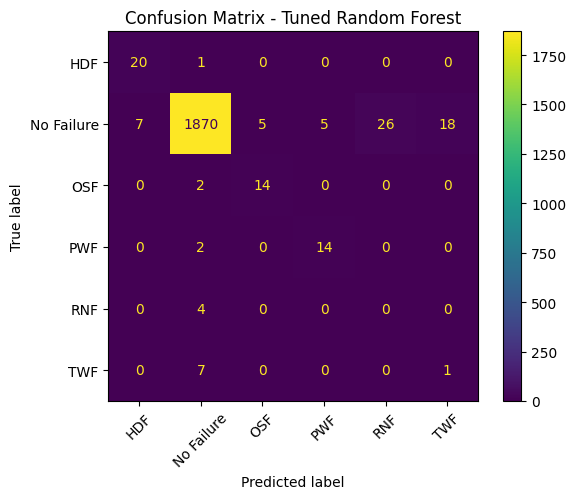

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tunned, labels=tunned_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tunned_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()